<div style="display: flex; background-color: RGB(0, 35, 160);" >
<h1 style="margin: auto; padding: 30px; color:#fff;">DETECTEZ DES FAUX BILLETS</h1>
</div>

<h1 style="color:RGB(31,119,180)">
ONCFM 
</h1>

<p>
<span style="color:RGB(31,119,180)">L'ONCFM (Organisation Nationale de lutte Contre le Faux-Monnayage) </span> est une organisation publique ayant pour objectif de mettre en place des méthodes d’identification des contrefaçons des billets en euros. 
<br />
Ce notebook contient le scrpt permettant de détecter les faux billets
</p>

<div style="background-color: RGB(31, 119, 180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(31, 119, 180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31, 119, 180); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import os
import joblib
from pathlib import Path

<div style="border: 1px solid RGB(31, 119, 180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31, 119, 180); ">1.2 - Chargement du modèle</h3>
</div>

In [204]:
# Chemin du modèle à importer
model_path = Path("modele/modele_pipeline_ofcm.joblib")

# Charge le modèle si le fichier 'joblib' est présent au bon emplacement
if not model_path.is_file():
        raise FileNotFoundError(f"Le fichier '{model_path}' est introuvable.")
else:
    modele = joblib.load(model_path)
    print('Chargement du modèle effectué avec succès.')

Chargement du modèle effectué avec succès.


<div style="border: 1px solid RGB(31, 119, 180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31, 119, 180); ">1.3 - Chargement du fichier</h3>
</div>

In [205]:
data_file_csv = input('Déposez le fichier dans le dossier data/in et entrez le nom du fichier. Le fichier doit avoir l\'extension CSV et avoir comme séparateur la virgule')

In [206]:
DATA_PATH = "data/in/"+data_file_csv

if not os.path.exists(DATA_PATH):
    print(f"Le fichier '{DATA_PATH}' n'existe pas.")

else:
    try:
        df_billets = pd.read_csv(DATA_PATH, sep=",")
        print("Le fichier contient {} lignes et {} colonnes".format(df_billets.shape[0], df_billets.shape[1]))
        display(df_billets.head(50))
    except Exception as e:
        print("Erreur lors du chargement :", e)


Le fichier contient 5 lignes et 7 colonnes


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


<div style="background-color: RGB(31, 119, 180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Vérification des données du fichier d'entrée</h2>
</div>

In [207]:
#On verifie que tous les features sont présents dans la dataset
feature_list = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

df_column_list = df_billets.columns

if not set(feature_list).issubset(set(df_column_list)):
    raise Exception("Il manque au moins une colonne dans le fichier d'entrée. Voici les colonnes que le fichier d'entrée doit contenir", feature_list)


In [208]:
#Vérification que toutes les colonnes features sont remplies
df_billets_features = df_billets[feature_list]

if df_billets_features.isna().any().any():
    raise Exception("Il manque des données dans le dataset")

<div style="background-color: RGB(31, 119, 180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Prédictions</h2>
</div>

In [209]:
#Récupération des prédictions
prediction = modele.predict(df_billets_features)

#Récupération des probabilités de prédictions
proba_prediction = modele.predict_proba(df_billets_features)

#Ajout des prédictions et des probabilités de prédictions dans la dataframe
df_billets["prediction"] = prediction
df_billets["proba_prediction_"+str(modele.classes_[0])] = proba_prediction[:,0]
df_billets["proba_prediction_"+str(modele.classes_[1])] = proba_prediction[:, 1]

#Affichage du dataframe
df_billets

,diagonal,height_left,height_right,margin_low,margin_up,length,id,prediction,proba_prediction_0,proba_prediction_1
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0,0.952222,0.047778
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0,0.996313,0.003687
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0,0.993866,0.006134
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,1,0.017330,0.982670
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,1,0.000547,0.999453


In [210]:
df_billets

,diagonal,height_left,height_right,margin_low,margin_up,length,id,prediction,proba_prediction_0,proba_prediction_1
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0,0.952222,0.047778
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0,0.996313,0.003687
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0,0.993866,0.006134
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,1,0.017330,0.982670
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,1,0.000547,0.999453


In [211]:
#Remplacement de la valeur des prédictions par True et False
df_billets.loc[:,'is_genuine'] =df_billets['prediction'].apply(
    lambda x: True if (x == 1) else False
)

#Recherhe de la probabilité la plus élevée
df_billets.loc[:,'proba_prediction'] =df_billets.apply(
    lambda x: x["proba_prediction_0"] if (x["proba_prediction_0"] >= 0.5) else x["proba_prediction_1"],
    axis = 1
)

#Affichage des résultats
df_billets.drop(['prediction',"proba_prediction_0","proba_prediction_1"], axis=1, inplace=True)
df_billets

,diagonal,height_left,height_right,margin_low,margin_up,length,id,is_genuine,proba_prediction
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,False,0.952222
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,False,0.996313
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,False,0.993866
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,True,0.982670
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,True,0.999453


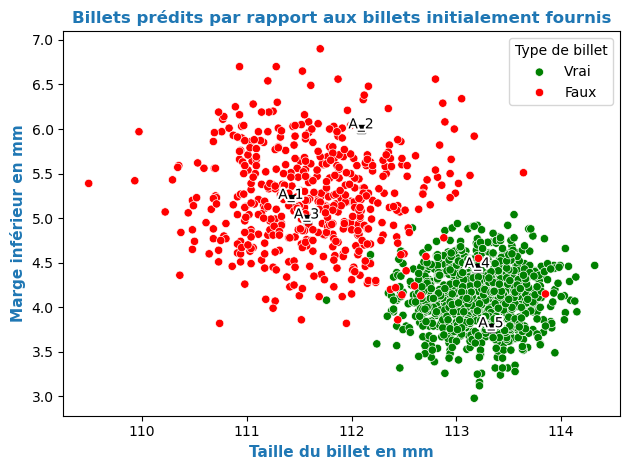

In [252]:
df_billets_orig = pd.read_csv("data/in/billets.csv", sep=";")

df_billets_not_missing_value_orig = df_billets_orig[df_billets_orig['margin_low'].notna()]
sns.scatterplot(data=df_billets_not_missing_value_orig, x = df_billets_not_missing_value_orig.length, y = df_billets_not_missing_value_orig.margin_low, hue='is_genuine', palette=["red","green"])

for df_billets_row in df_billets.itertuples():
    plt.plot(df_billets_row.length, df_billets_row.margin_low,  marker="s", c="black")
    plt.text(df_billets_row.length, df_billets_row.margin_low+0.05, df_billets_row.id, fontsize='10', color="black", path_effects=[pe.withStroke(linewidth=3, foreground="white")], ha='center',va='center')
 
plt.ylabel('Marge inférieur en mm', fontsize=11, color="#1F77B4", weight="bold")
plt.xlabel('Taille du billet en mm', fontsize=11, color="#1F77B4", weight="bold")
plt.title("Billets prédits par rapport aux billets initialement fournis", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(title="Type de billet", loc="best", labels=["Vrai","Faux"])

plt.tight_layout()
plt.show()

In [213]:
print("Liste des faux billets")

df_billets_fake = df_billets[df_billets["is_genuine"] == False]

display(df_billets_fake)

Liste des faux billets


,diagonal,height_left,height_right,margin_low,margin_up,length,id,is_genuine,proba_prediction
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,False,0.952222
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,False,0.996313
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,False,0.993866


<div style="background-color: RGB(31, 119, 180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Export du fichier des prédictions</h2>
</div>

In [214]:
df_billets.to_csv(path_or_buf='data/out/df_billets_production_prediction.csv', sep=";", index=False)
